<a href="https://colab.research.google.com/github/faith-dev122/BIT4133-NLP-Project/blob/main/Week_6_to_7_Practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# WEEK 6
# WEEK 6 - Setup: Install Gensim
!pip install gensim --quiet

import gensim
print("Gensim version:", gensim.__version__)
print("Ready for Word2Vec!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.6 MB/s eta 0:00:00
Gensim version: 4.4.0
Ready for Word2Vec!


In [2]:
# Class Activity 1: One-Hot Encoding vs Word Embeddings
# Compare Cat, Dog Animal using both methods
import numpy as np

print("METHOD 1: ONE-HOT ENCODING")
print("=" * 55)

vocab = ['cat', 'dog', 'animal']
print(f"Vocabulary: {vocab}\n")

one_hot = {
    'cat'   : [1, 0, 0],
    'dog'   : [0, 1, 0],
    'animal': [0, 0, 1]
}

for word, vec in one_hot.items():
    print(f"  {word:<10} → {vec}")

print("\nPROBLEM: 'cat' and 'animal' are clearly related in meaning,")
print("but their one-hot vectors are completely different —")
print("there is NO mathematical relationship between them.")

# Cosine similarity for one-hot vectors
def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"\nSimilarity(cat, animal) = {cosine_sim(one_hot['cat'], one_hot['animal']):.2f}")
print(f"Similarity(cat, dog)    = {cosine_sim(one_hot['cat'], one_hot['dog']):.2f}")
print("Both scores are 0 — One-Hot Encoding cannot capture meaning!")

METHOD 1: ONE-HOT ENCODING
Vocabulary: ['cat', 'dog', 'animal']

  cat        → [1, 0, 0]
  dog        → [0, 1, 0]
  animal     → [0, 0, 1]

PROBLEM: 'cat' and 'animal' are clearly related in meaning,
but their one-hot vectors are completely different —
there is NO mathematical relationship between them.

Similarity(cat, animal) = 0.00
Similarity(cat, dog)    = 0.00
Both scores are 0 — One-Hot Encoding cannot capture meaning!


In [3]:
# Class Demonstration 2 & Practical Task 1
# Train a Word2Vec Model
from gensim.models import Word2Vec

# A slightly bigger dataset
# More sentences = better embeddings
sentences = [
    ["i","love","nlp"],
    ["nlp","is","interesting"],
    ["machine","learning","is","powerful"],
    ["i","love","machine","learning"],
    ["deep","learning","is","part","of","machine","learning"],
    ["nlp","uses","deep","learning"],
    ["the","cat","drinks","milk"],
    ["the","dog","drinks","milk"],
    ["the","cat","and","dog","are","animals"],
    ["i","love","my","cat","and","dog"],
    ["python","is","used","for","machine","learning"],
    ["nlp","and","machine","learning","are","related"],
    ["the","student","loves","studying","nlp"],
    ["the","teacher","explains","machine","learning"],
    ["king","and","queen","rule","the","kingdom"],
    ["the","king","is","powerful"],
    ["the","queen","is","wise"],
    ["man","and","woman","live","in","the","kingdom"]
]

model = Word2Vec(
    sentences,
    vector_size=50,   # each word becomes a list of 50 numbers
    window=2,         # looks at 2 words before and after
    min_count=1,       # include words that appear at least once
    workers=4
)

print("WORD2VEC MODEL TRAINED")
print("=" * 55)
print(f"Vocabulary size: {len(model.wv.index_to_key)} words")
print(f"Vocabulary: {model.wv.index_to_key}")

print(f"\nVector for 'nlp' (first 10 of 50 dimensions):")
print(model.wv["nlp"][:10])
print(f"\nFull vector shape: {model.wv['nlp'].shape}")

WORD2VEC MODEL TRAINED
Vocabulary size: 39 words
Vocabulary: ['the', 'learning', 'machine', 'is', 'and', 'nlp', 'dog', 'cat', 'love', 'i', 'kingdom', 'queen', 'king', 'are', 'milk', 'drinks', 'deep', 'powerful', 'in', 'live', 'woman', 'man', 'wise', 'rule', 'explains', 'teacher', 'studying', 'loves', 'student', 'related', 'for', 'used', 'python', 'my', 'animals', 'uses', 'of', 'part', 'interesting']

Vector for 'nlp' (first 10 of 50 dimensions):
[ 0.00288561 -0.00530133 -0.01414526 -0.01561474 -0.01824137 -0.01187366
 -0.00368822 -0.00863179 -0.01291255 -0.0074363 ]

Full vector shape: (50,)


In [6]:
# WEEK 6 Class Demonstration 3 & Practical Task 2
# Finding Similar Words and Similarity Scores
print("MOST SIMILAR WORDS TO 'nlp':")
print("=" * 55)
for word, score in model.wv.most_similar("nlp", topn=5):
    print(f"  {word:<15} → similarity: {score:.4f}")

print("\nMOST SIMILAR WORDS TO 'cat':")
print("=" * 55)
for word, score in model.wv.most_similar("cat", topn=5):
    print(f"  {word:<15} → similarity: {score:.4f}")

print("\nMOST SIMILAR WORDS TO 'king':")
print("=" * 55)
for word, score in model.wv.most_similar("king", topn=5):
    print(f"  {word:<15} → similarity: {score:.4f}")


# Practical Task 2: Select 10 words and compute similarity scores
print("\n\nPRACTICAL TASK 2: SIMILARITY ANALYSIS — 10 WORD PAIRS")
print("=" * 55)

word_pairs = [
    ("nlp", "learning"),
    ("cat", "dog"),
    ("cat", "animals"), # Changed 'animal' to 'animals'
    ("king", "queen"),
    ("king", "kingdom"),
    ("machine", "learning"),
    ("deep", "learning"),
    ("nlp", "python"),
    ("student", "teacher"),
    ("man", "woman")
]

for w1, w2 in word_pairs:
    score = model.wv.similarity(w1, w2)
    print(f"  similarity('{w1}', '{w2}') = {score:.4f}")

MOST SIMILAR WORDS TO 'nlp':
  are             → similarity: 0.3062
  powerful        → similarity: 0.2705
  i               → similarity: 0.2246
  teacher         → similarity: 0.2147
  rule            → similarity: 0.2052

MOST SIMILAR WORDS TO 'cat':
  part            → similarity: 0.2398
  love            → similarity: 0.1847
  wise            → similarity: 0.1713
  powerful        → similarity: 0.1663
  loves           → similarity: 0.1435

MOST SIMILAR WORDS TO 'king':
  my              → similarity: 0.1907
  is              → similarity: 0.1906
  milk            → similarity: 0.1887
  python          → similarity: 0.1845
  interesting     → similarity: 0.1754


PRACTICAL TASK 2: SIMILARITY ANALYSIS — 10 WORD PAIRS
  similarity('nlp', 'learning') = 0.0183
  similarity('cat', 'dog') = 0.1132
  similarity('cat', 'animals') = 0.0590
  similarity('king', 'queen') = 0.1747
  similarity('king', 'kingdom') = -0.1699
  similarity('machine', 'learning') = 0.0112
  similarity('deep', 'lear

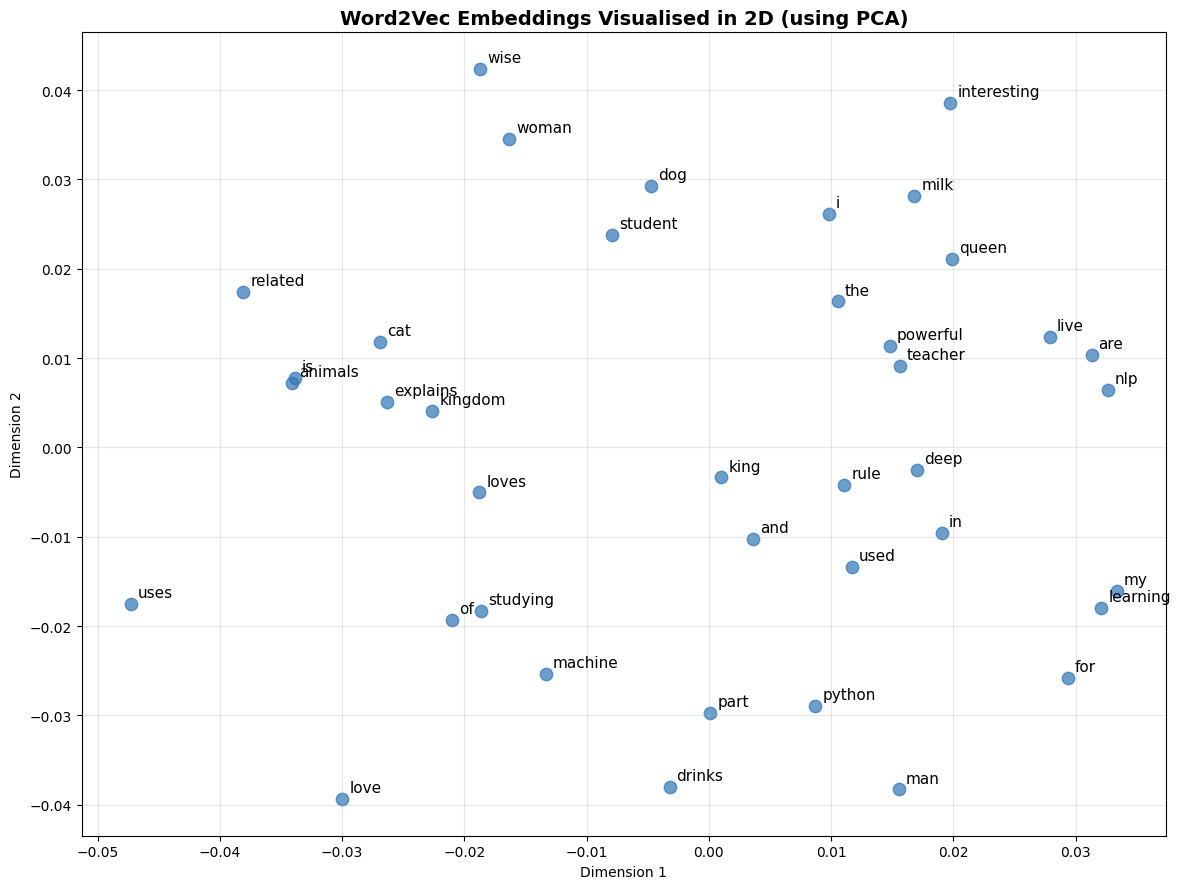

PCA visualisation saved.

Notice: words that appear in similar contexts cluster together
e.g. 'cat' and 'dog' should be close, 'king' and 'queen' should be close


In [7]:
# Class Demonstration 5
# Visualizing Word Embeddings using PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Get all word vectors
words   = model.wv.index_to_key
vectors = np.array([model.wv[word] for word in words])

# Reduce 50 dimensions down to 2 for plotting
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(12, 9))
plt.scatter(reduced[:, 0], reduced[:, 1], color='#2E75B6', s=80, alpha=0.7)

for i, word in enumerate(words):
    plt.annotate(word, xy=(reduced[i, 0], reduced[i, 1]),
                  xytext=(5, 5), textcoords='offset points', fontsize=11)

plt.title('Word2Vec Embeddings Visualised in 2D (using PCA)',
          fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('word2vec_pca.png', dpi=150)
plt.show()
print("PCA visualisation saved.")
print("\nNotice: words that appear in similar contexts cluster together")
print("e.g. 'cat' and 'dog' should be close, 'king' and 'queen' should be close")

In [8]:
# WEEK 6 - Practical Task 3: Comparison Report
# One-Hot Encoding vs Word Embeddings

print("COMPARISON REPORT: One-Hot Encoding vs Word Embeddings")
print("=" * 70)

comparison = [
    ("Size",
     "Vector size = vocabulary size (can be 1000s)",
     "Fixed small size (e.g. 50, 100, 300) regardless of vocabulary"),

    ("Meaning Representation",
     "No meaning captured — purely an ID",
     "Captures semantic meaning — similar words have similar vectors"),

    ("Efficiency",
     "Memory inefficient — mostly zeros (sparse)",
     "Memory efficient — dense, compact vectors"),

    ("Semantic Understanding",
     "None — 'cat' and 'animal' are unrelated mathematically",
     "Strong — 'cat' and 'animal' are close in vector space"),
]

print(f"{'Feature':<25} {'One-Hot Encoding':<40} {'Word Embeddings'}")
print("-" * 110)
for feature, onehot, embedding in comparison:
    print(f"{feature:<25} {onehot:<40} {embedding}")

print("\nCONCLUSION:")
print("-" * 70)
print("One-Hot Encoding treats every word as completely independent —")
print("it has no concept of meaning or relationships between words.")
print("Word Embeddings solve this by learning dense vectors from context,")
print("allowing the model to understand that 'cat' is closer to 'dog'")
print("than it is to 'car'. This is why every modern NLP system —")
print("chatbots, translators, search engines — uses embeddings.")

COMPARISON REPORT: One-Hot Encoding vs Word Embeddings
Feature                   One-Hot Encoding                         Word Embeddings
--------------------------------------------------------------------------------------------------------------
Size                      Vector size = vocabulary size (can be 1000s) Fixed small size (e.g. 50, 100, 300) regardless of vocabulary
Meaning Representation    No meaning captured — purely an ID       Captures semantic meaning — similar words have similar vectors
Efficiency                Memory inefficient — mostly zeros (sparse) Memory efficient — dense, compact vectors
Semantic Understanding    None — 'cat' and 'animal' are unrelated mathematically Strong — 'cat' and 'animal' are close in vector space

CONCLUSION:
----------------------------------------------------------------------
One-Hot Encoding treats every word as completely independent —
it has no concept of meaning or relationships between words.
Word Embeddings solve this by lear

In [9]:
# WEEK 6 EXTRA: CBOW vs Skip-Gram Comparison
# Train both architectures and compare results
from gensim.models import Word2Vec
import time

print("CBOW vs SKIP-GRAM COMPARISON")
print("=" * 60)
print("CBOW (sg=0): Predicts target word FROM surrounding words")
print("Skip-Gram (sg=1): Predicts surrounding words FROM target word\n")

# Train CBOW model
start = time.time()
model_cbow = Word2Vec(sentences, vector_size=50, window=2,
                       min_count=1, sg=0, workers=4)
cbow_time = time.time() - start

# Train Skip-Gram model
start = time.time()
model_skipgram = Word2Vec(sentences, vector_size=50, window=2,
                           min_count=1, sg=1, workers=4)
skipgram_time = time.time() - start

print(f"CBOW training time     : {cbow_time:.4f} seconds")
print(f"Skip-Gram training time: {skipgram_time:.4f} seconds")

print(f"\nMost similar to 'nlp' — CBOW:")
for word, score in model_cbow.wv.most_similar("nlp", topn=3):
    print(f"  {word:<15} → {score:.4f}")

print(f"\nMost similar to 'nlp' — Skip-Gram:")
for word, score in model_skipgram.wv.most_similar("nlp", topn=3):
    print(f"  {word:<15} → {score:.4f}")

print("\nOBSERVATION:")
print("CBOW trains faster and works well for frequent words.")
print("Skip-Gram is slower but produces better embeddings")
print("for rare words because it generates more training pairs")
print("from each occurrence of a word.")

CBOW vs SKIP-GRAM COMPARISON
CBOW (sg=0): Predicts target word FROM surrounding words
Skip-Gram (sg=1): Predicts surrounding words FROM target word

CBOW training time     : 0.0133 seconds
Skip-Gram training time: 0.0095 seconds

Most similar to 'nlp' — CBOW:
  are             → 0.3062
  powerful        → 0.2705
  i               → 0.2246

Most similar to 'nlp' — Skip-Gram:
  are             → 0.3066
  powerful        → 0.2703
  i               → 0.2246

OBSERVATION:
CBOW trains faster and works well for frequent words.
Skip-Gram is slower but produces better embeddings
for rare words because it generates more training pairs
from each occurrence of a word.


In [10]:
# WEEK 7 Class Demonstration 1: Install TensorFlow
!pip install tensorflow --quiet

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Ready for Neural Language Models!")

TensorFlow version: 2.20.0
Ready for Neural Language Models!


In [11]:
# WEEK 7
# WEEK 7 Class Demonstration 2: Creating a Simple Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_nn = Sequential()
model_nn.add(Dense(8, activation='relu', input_shape=(4,)))
model_nn.add(Dense(4, activation='relu'))
model_nn.add(Dense(1))

model_nn.summary()

print("\nEXPLANATION:")
print("-" * 55)
print("Input Layer  : Receives 4 numbers as input")
print("Hidden Layer 1: 8 neurons, ReLU activation")
print("Hidden Layer 2: 4 neurons, ReLU activation")
print("Output Layer : 1 neuron — produces the final prediction")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)


EXPLANATION:
-------------------------------------------------------
Input Layer  : Receives 4 numbers as input
Hidden Layer 1: 8 neurons, ReLU activation
Hidden Layer 2: 4 neurons, ReLU activation
Output Layer : 1 neuron — produces the final prediction


In [12]:
# WEEK 7 Class Demonstrations 3 & 4
# Text Tokenization and Sequences (TensorFlow)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = [
    "I love NLP",
    "NLP is interesting",
    "Machine learning is powerful",
    "I love machine learning",
    "Deep learning is part of NLP"
]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

print("WORD INDEX (Vocabulary mapping):")
print("=" * 55)
print(tokenizer.word_index)

sequences = tokenizer.texts_to_sequences(texts)
print("\nTEXT CONVERTED TO SEQUENCES:")
print("=" * 55)
for text, seq in zip(texts, sequences):
    print(f"  '{text}' → {seq}")

# Pad sequences so they are all the same length
padded = pad_sequences(sequences, padding='post')
print("\nPADDED SEQUENCES (equal length for neural network input):")
print("=" * 55)
print(padded)

WORD INDEX (Vocabulary mapping):
{'nlp': 1, 'is': 2, 'learning': 3, 'i': 4, 'love': 5, 'machine': 6, 'interesting': 7, 'powerful': 8, 'deep': 9, 'part': 10, 'of': 11}

TEXT CONVERTED TO SEQUENCES:
  'I love NLP' → [4, 5, 1]
  'NLP is interesting' → [1, 2, 7]
  'Machine learning is powerful' → [6, 3, 2, 8]
  'I love machine learning' → [4, 5, 6, 3]
  'Deep learning is part of NLP' → [9, 3, 2, 10, 11, 1]

PADDED SEQUENCES (equal length for neural network input):
[[ 4  5  1  0  0  0]
 [ 1  2  7  0  0  0]
 [ 6  3  2  8  0  0]
 [ 4  5  6  3  0  0]
 [ 9  3  2 10 11  1]]


In [13]:
# WEEK 7 Practical Task 1: Text Prediction System
# A neural network that predicts the next word
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# STEP 1: Create a small dataset
text_data = """
natural language processing helps computers understand human language
machine learning is a part of artificial intelligence
deep learning uses neural networks to process data
nlp is used in chatbots and search engines
word embeddings capture the meaning of words
neural networks learn patterns from large amounts of data
the student is studying for the exam
the cat drinks milk every morning
the dog plays in the garden every day
artificial intelligence is transforming the world
"""

# STEP 2: Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_data])
total_words = len(tokenizer.word_index) + 1

print("TOKENIZATION COMPLETE")
print(f"Total unique words: {total_words}")

# STEP 3: Create input sequences (n-gram style)
input_sequences = []
for line in text_data.split('\n'):
    if line.strip() == "":
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total training sequences: {len(input_sequences)}")
print(f"Example sequence: {input_sequences[5]}")

# STEP 4: Pad sequences
max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

# STEP 5: Split into X (input) and y (word to predict)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# STEP 6: Build the Neural Language Model
model_nlm = Sequential([
    Embedding(total_words, 16, input_length=max_seq_len-1),
    LSTM(50),
    Dense(total_words, activation='softmax')
])

model_nlm.compile(loss='categorical_crossentropy',
                   optimizer='adam', metrics=['accuracy'])

model_nlm.summary()

TOKENIZATION COMPLETE
Total unique words: 56
Total training sequences: 65
Example sequence: [13, 4, 14, 15, 16, 17, 18]

X shape: (65, 8)
y shape: (65, 56)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Practical Task 1 continued: Train the model
print("TRAINING THE NEURAL LANGUAGE MODEL...")
print("=" * 55)

history = model_nlm.fit(X, y, epochs=100, verbose=1)

print("\nTraining complete!")
print(f"Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")

TRAINING THE NEURAL LANGUAGE MODEL...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0000e+00 - loss: 4.0260
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0308 - loss: 4.0218    
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0615 - loss: 4.0188
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0615 - loss: 4.0161
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0615 - loss: 4.0129    
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0615 - loss: 4.0097
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0615 - loss: 4.0062
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0615 - loss: 4.0023
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0615 - loss: 3.9983
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0615 - loss: 3.9938
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0615 - loss: 3.9894
Epoch 12/100
3/3 ━━━━━━━

In [15]:
# WEEK 7 Predict the Next Word (with confidence score)
# This is the Advanced Practical Task feature

def predict_next_word(seed_text, top_n=3):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

    predicted_probs = model_nlm.predict(token_list, verbose=0)[0]

    # Get top N predictions with confidence
    top_indices = predicted_probs.argsort()[-top_n:][::-1]

    print(f"\nInput phrase: '{seed_text}'")
    print(f"Top {top_n} predictions:")
    for idx in top_indices:
        word = tokenizer.index_word.get(idx, '?')
        confidence = predicted_probs[idx] * 100
        print(f"  '{word}'  →  confidence: {confidence:.2f}%")

# Test the predictor
print("NEXT WORD PREDICTION SYSTEM")
print("=" * 55)

test_phrases = [
    "natural language",
    "the student is studying for the",
    "the cat drinks",
    "machine learning is a part of",
    "artificial intelligence is"
]

for phrase in test_phrases:
    predict_next_word(phrase, top_n=3)

NEXT WORD PREDICTION SYSTEM

Input phrase: 'natural language'
Top 3 predictions:
  'is'  →  confidence: 12.09%
  'the'  →  confidence: 7.99%
  'learning'  →  confidence: 7.47%

Input phrase: 'the student is studying for the'
Top 3 predictions:
  'the'  →  confidence: 8.57%
  'of'  →  confidence: 3.94%
  'in'  →  confidence: 3.82%

Input phrase: 'the cat drinks'
Top 3 predictions:
  'the'  →  confidence: 16.46%
  'is'  →  confidence: 9.27%
  'in'  →  confidence: 6.63%

Input phrase: 'machine learning is a part of'
Top 3 predictions:
  'of'  →  confidence: 5.25%
  'large'  →  confidence: 3.71%
  'to'  →  confidence: 2.95%

Input phrase: 'artificial intelligence is'
Top 3 predictions:
  'the'  →  confidence: 13.23%
  'is'  →  confidence: 11.10%
  'in'  →  confidence: 5.82%


In [16]:
# WEEK 7: N-Gram vs Neural Language Model

print("COMPARISON: N-Gram Model vs Neural Language Model")
print("=" * 70)

comparison = [
    ("Context Understanding",
     "Limited — only looks at fixed N previous words",
     "Strong — LSTM remembers long-range context"),

    ("Memory Usage",
     "Grows huge — must store every word combination seen",
     "Compact — fixed-size weights regardless of vocabulary"),

    ("Semantic Learning",
     "None — 'teacher' and 'instructor' treated as unrelated",
     "Yes — learns that similar words behave similarly"),

    ("Prediction Accuracy",
     "Poor on unseen word combinations (data sparsity)",
     "Better — generalises to combinations never seen before"),
]

print(f"{'Feature':<25} {'N-Gram Model':<40} {'Neural Language Model'}")
print("-" * 110)
for feature, ngram, nlm in comparison:
    print(f"{feature:<25} {ngram:<40} {nlm}")

print("\nCONCLUSION:")
print("Our SMS Spam Classifier (Project 1) used TF-IDF + N-grams —")
print("a traditional approach. This Week 7 model uses an LSTM neural")
print("network — a modern approach. The neural model can generalise")
print("to sentences it has never seen, while the N-gram model cannot.")

COMPARISON: N-Gram Model vs Neural Language Model
Feature                   N-Gram Model                             Neural Language Model
--------------------------------------------------------------------------------------------------------------
Context Understanding     Limited — only looks at fixed N previous words Strong — LSTM remembers long-range context
Memory Usage              Grows huge — must store every word combination seen Compact — fixed-size weights regardless of vocabulary
Semantic Learning         None — 'teacher' and 'instructor' treated as unrelated Yes — learns that similar words behave similarly
Prediction Accuracy       Poor on unseen word combinations (data sparsity) Better — generalises to combinations never seen before

CONCLUSION:
Our SMS Spam Classifier (Project 1) used TF-IDF + N-grams —
a traditional approach. This Week 7 model uses an LSTM neural
network — a modern approach. The neural model can generalise
to sentences it has never seen, while the N-gr